<a href="https://colab.research.google.com/github/Erica4397/for_coding_camp1/blob/main/ForCodingCampNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questions(listed from most to least interested)

How does the max_wind_knots, min_pressure_mb and more differ in a long lasting hurricane vs a shorter one?

Are there more hurricanes/storms(be more specific - what type/category?) happening more frequently than before? Why?

How does the max_wind_knots, min_pressure_mb and more change as a hurricane progresses?

Import everything

In [3]:
!pip install pandas
import pandas as pd
!pip install matplotlib
import matplotlib.pyplot as plt

Load in the dataset and take a look at it

In [6]:
df = pd.read_csv("hurdat2_atlantic_1851_2025_filtered.csv")
#df.head()
#df['status'].unique()
#df['record_identifier'].unique()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   storm_id           55605 non-null  object 
 1   name               55605 non-null  object 
 2   date               55605 non-null  object 
 3   time               55605 non-null  int64  
 4   record_identifier  1256 non-null   object 
 5   status             55605 non-null  object 
 6   latitude           55605 non-null  float64
 7   longitude          55605 non-null  float64
 8   max_wind_knots     55605 non-null  int64  
 9   min_pressure_mb    24659 non-null  float64
 10  year               55605 non-null  int64  
 11  month              55605 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 5.1+ MB


Drop duplicates

In [9]:
df_nodup = df.drop_duplicates()
df_nodup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   storm_id           55605 non-null  object 
 1   name               55605 non-null  object 
 2   date               55605 non-null  object 
 3   time               55605 non-null  int64  
 4   record_identifier  1256 non-null   object 
 5   status             55605 non-null  object 
 6   latitude           55605 non-null  float64
 7   longitude          55605 non-null  float64
 8   max_wind_knots     55605 non-null  int64  
 9   min_pressure_mb    24659 non-null  float64
 10  year               55605 non-null  int64  
 11  month              55605 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 5.1+ MB


Deal with null values

In [10]:
df_nodup[df_nodup.isna().any(axis=1)]

,storm_id,name,date,time,record_identifier,status,latitude,longitude,max_wind_knots,min_pressure_mb,year,month
0,AL011851,UNNAMED,1851-06-25,0,NaN,HU,28.0,-94.8,80,NaN,1851,6
1,AL011851,UNNAMED,1851-06-25,600,NaN,HU,28.0,-95.4,80,NaN,1851,6
2,AL011851,UNNAMED,1851-06-25,1200,NaN,HU,28.0,-96.0,80,NaN,1851,6
3,AL011851,UNNAMED,1851-06-25,1800,NaN,HU,28.1,-96.5,80,NaN,1851,6
4,AL011851,UNNAMED,1851-06-25,2100,L,HU,28.2,-96.8,80,NaN,1851,6
...,...,...,...,...,...,...,...,...,...,...,...,...
55600,AL132025,MELISSA,2025-10-31,600,NaN,HU,34.5,-65.5,75,972.0,2025,10
55601,AL132025,MELISSA,2025-10-31,1200,NaN,EX,37.7,-62.1,75,972.0,2025,10
55602,AL132025,MELISSA,2025-10-31,1800,NaN,EX,40.6,-58.9,70,972.0,2025,10
55603,AL132025,MELISSA,2025-11-01,0,NaN,EX,43.7,-56.0,70,971.0,2025,11


Scatter plot of the location of hurricanes

Text(0, 0.5, 'Longitude')

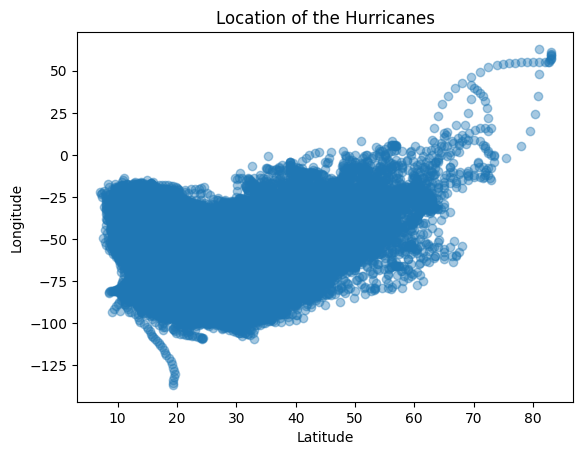

In [11]:
plt.scatter(df_nodup['latitude'], df_nodup['longitude'], alpha = 0.4)
plt.title('Location of the Hurricanes')
plt.xlabel('Latitude')
plt.ylabel('Longitude')

___

Text(0, 0.5, 'Storm id')

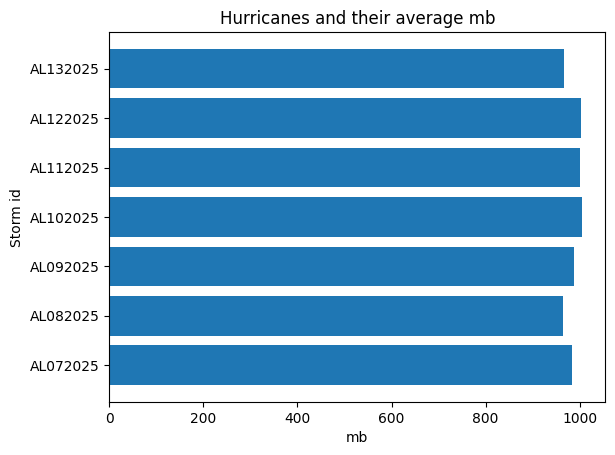

In [12]:
df_last_200r = df.tail(200)
means = df_last_200r.groupby('storm_id')['min_pressure_mb'].mean()
plt.barh(means.index, means.values)

plt.title('Hurricanes and their average mb')
plt.xlabel('mb')
plt.ylabel('Storm id')

Hurricane's pressure over time(longer)

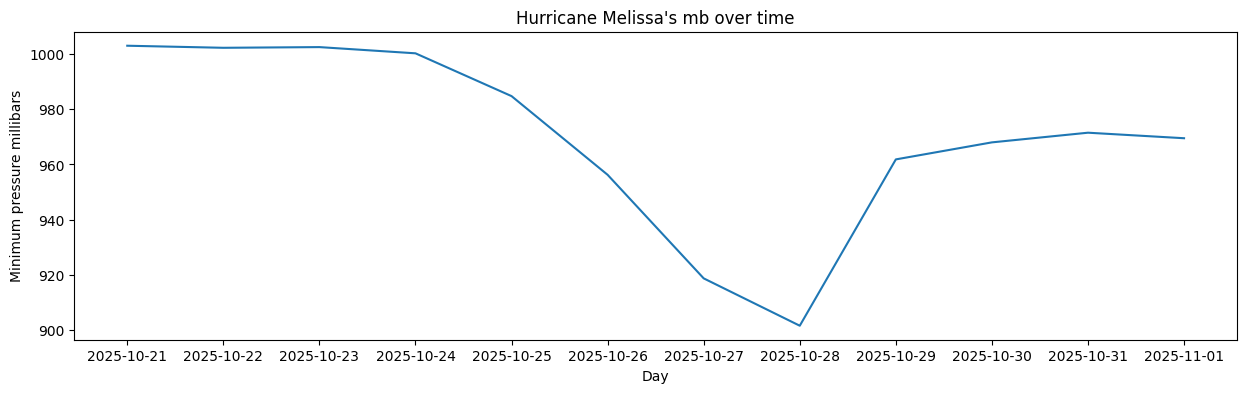

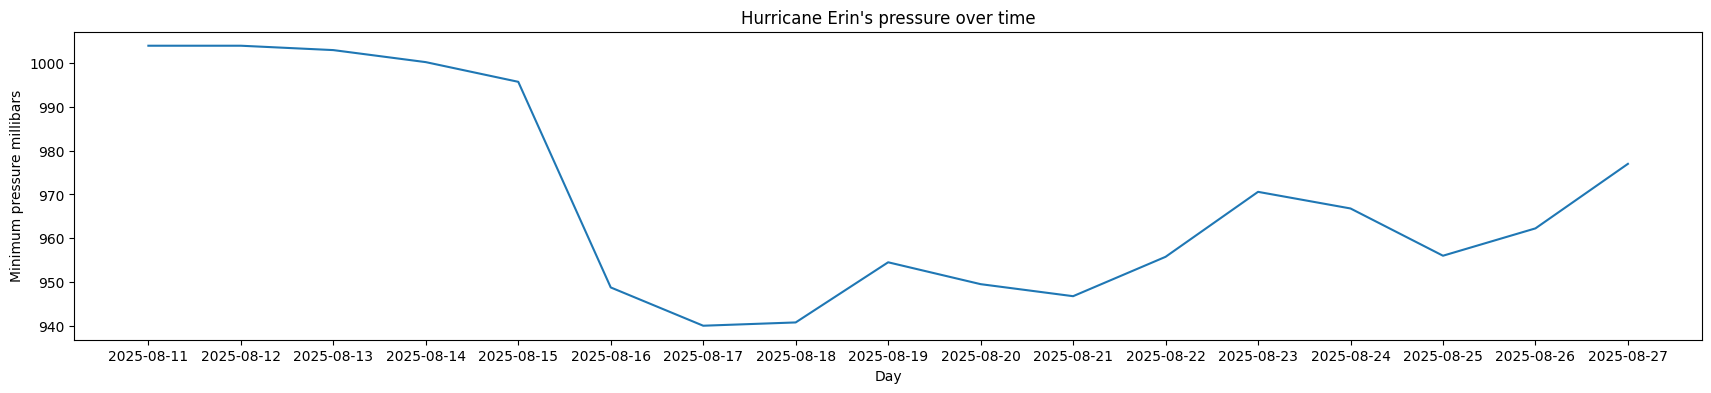

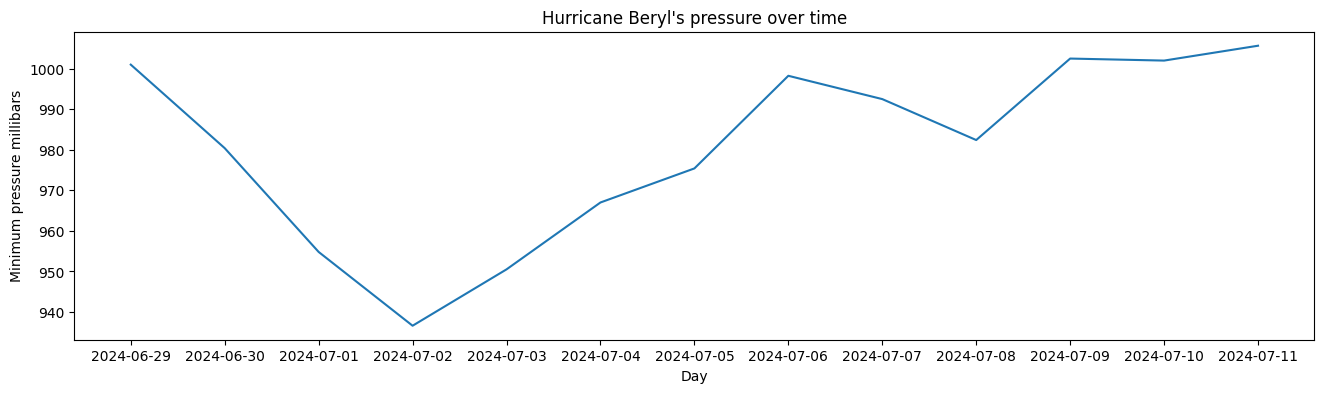

In [13]:
#lasted around 10 days
#lowest point was 892(row 55586). Longitude was -78.1, latitude was 17.5.
#Note: lower mb means worse weather. Usually, the mb of the standard atmosphere is 1013.25
df_melissa = df_nodup.tail(49)

#x axis
df_m_mb = df_melissa.groupby('date')['min_pressure_mb'].mean()
df_m_mb = df_m_mb.reset_index()

plt.figure(figsize=(15, 4))
plt.plot(df_m_mb['date'], df_m_mb['min_pressure_mb'])
plt.title("Hurricane Melissa's mb over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')
plt.show()

################################################################################
df_erin = df_nodup[55314:55382]
df_e_date = df_erin.groupby('date')['min_pressure_mb'].mean()
df_e_date = df_e_date.reset_index()

plt.figure(figsize=(21, 4))
plt.plot(df_e_date['date'], df_e_date['min_pressure_mb'])

plt.title("Hurricane Erin's pressure over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')

#lasted about 17 days
plt.show
################################################################################

df_beryl = df_nodup[54762:54818]
df_b_date = df_beryl.groupby('date')['min_pressure_mb'].mean()
df_b_date = df_b_date.reset_index()

plt.figure(figsize=(16, 4))
plt.plot(df_b_date['date'], df_b_date['min_pressure_mb'])

plt.title("Hurricane Beryl's pressure over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')
# lasted about 14 days
plt.show()

Wind knots of longer lasting hurricanes/storms

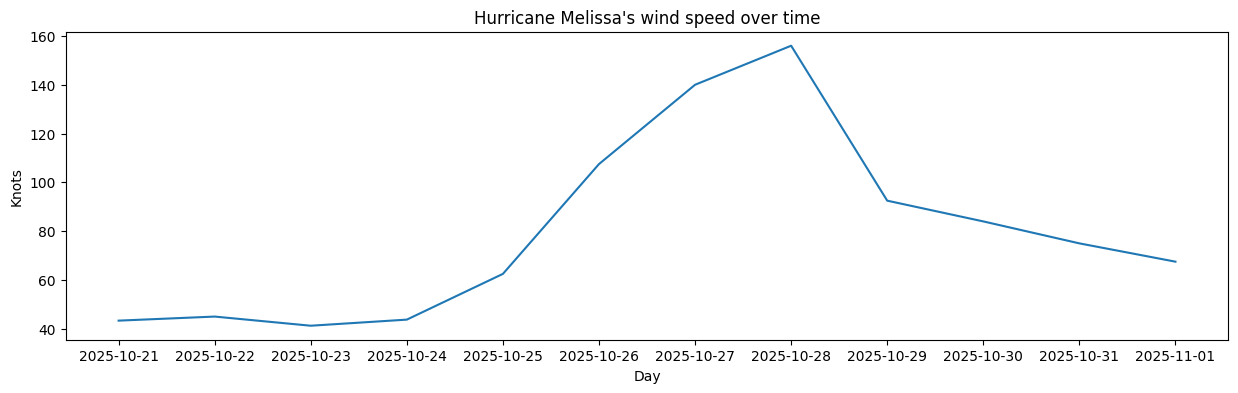

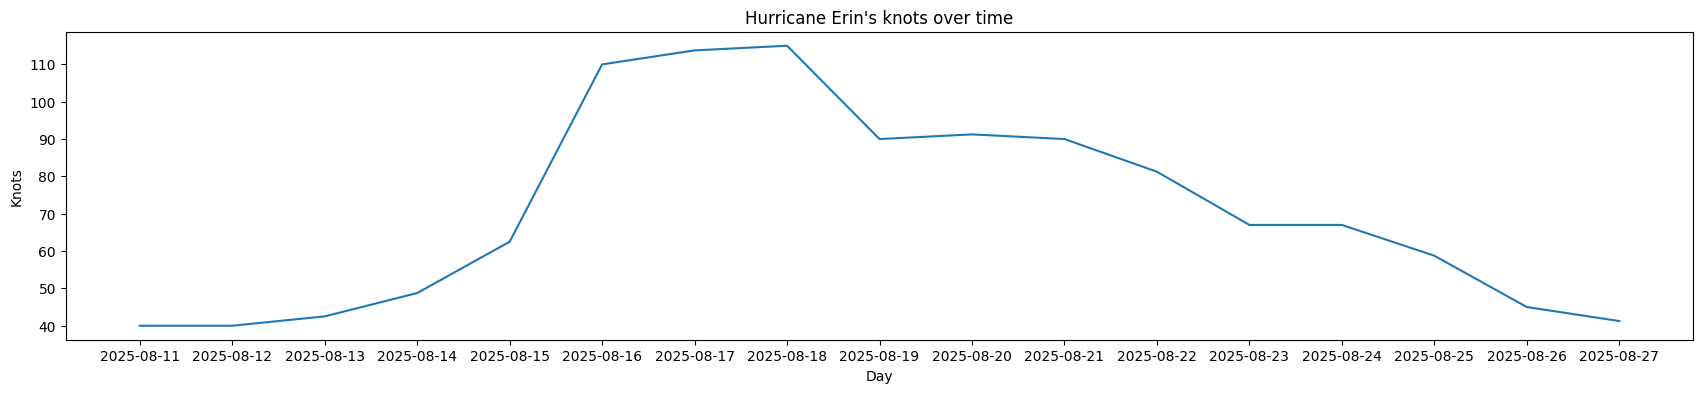

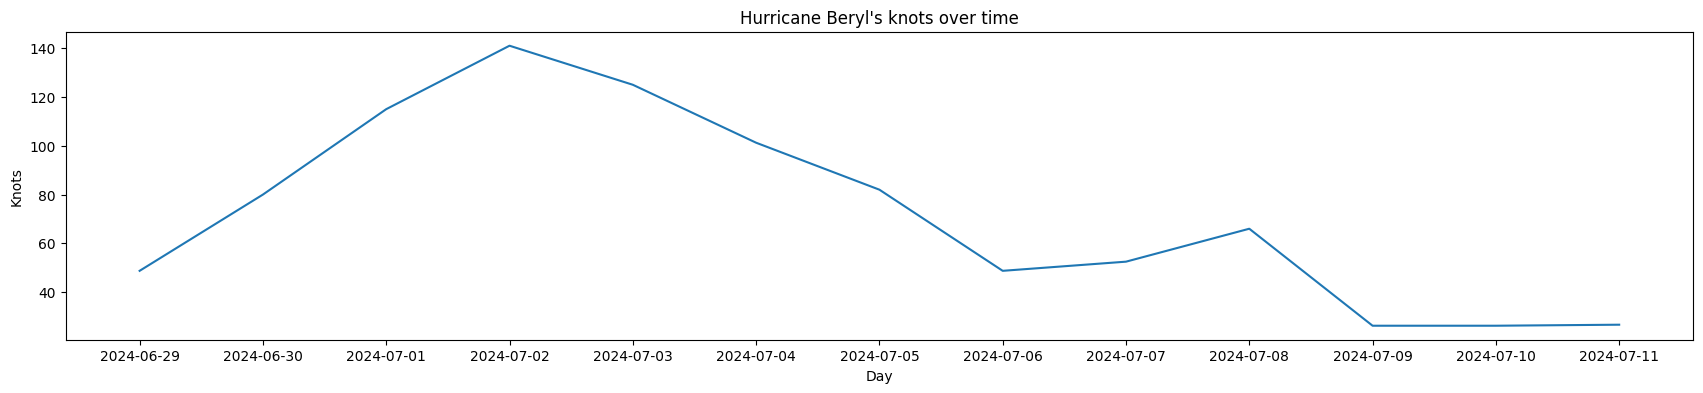

In [14]:
#1kn is about 1.15 mph or 1.85 km/h
#The point where the knot is highest is when the mb is lowest.
#TS-->HU-->EX
df_m_knot = df_melissa.groupby('date')['max_wind_knots'].mean()
df_m_knot = df_m_knot.reset_index()

plt.figure(figsize=(15, 4))
plt.plot(df_m_knot['date'], df_m_knot['max_wind_knots'])

plt.title("Hurricane Melissa's wind speed over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()
################################################################################
df_e_knot = df_erin.groupby('date')['max_wind_knots'].mean()
df_e_knot = df_e_knot.reset_index()

plt.figure(figsize=(21, 4))
plt.plot(df_e_knot['date'], df_e_knot['max_wind_knots'])

plt.title("Hurricane Erin's knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()
################################################################################
df_b_knot = df_beryl.groupby('date')['max_wind_knots'].mean()
df_b_knot = df_b_knot.reset_index()

plt.figure(figsize=(21, 4))
plt.plot(df_b_knot['date'], df_b_knot['max_wind_knots'])

plt.title("Hurricane Beryl's knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()

_______

Pressure over time(shorter)

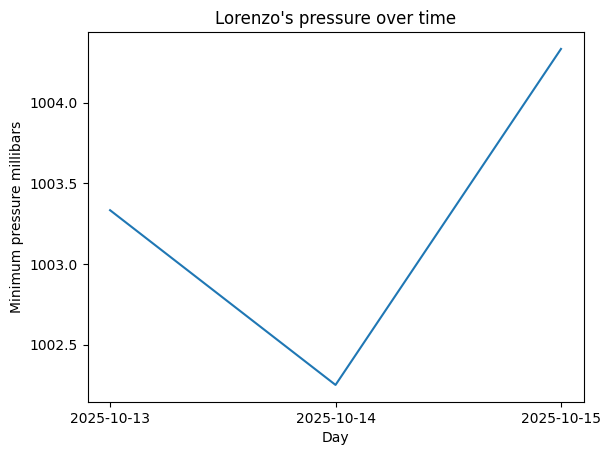

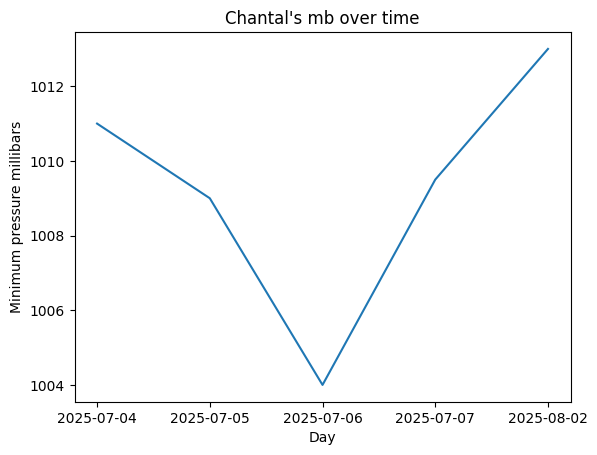

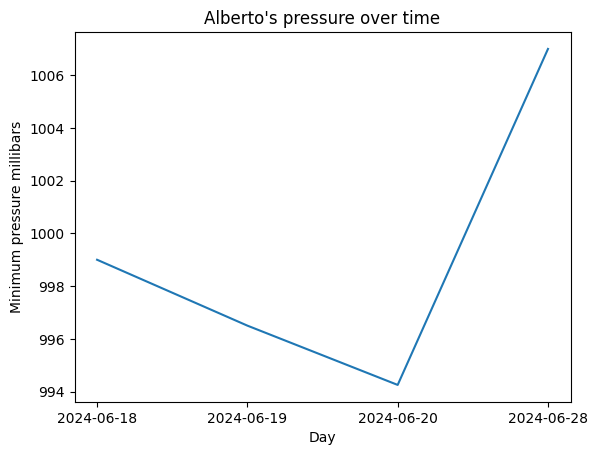

In [15]:
#define shorter storms as under _ days
#shorter storms don't usually go under ___ mb
#lasted around 3 days, lowest point was 1000

#FIX THE DATES FOR THE LATER TWO

df_lorenzo = df_nodup[55546:55556]
df_l_date = df_lorenzo.groupby('date')['min_pressure_mb'].mean()
df_l_date = df_l_date.reset_index()

plt.plot(df_l_date['date'], df_l_date['min_pressure_mb'])

plt.title("Lorenzo's pressure over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')

plt.show()
################################################################################
#lasted around 5 days, lowest point was 1002
df_chantal = df_nodup[55255:55270]
df_c_date = df_chantal.groupby('date')['min_pressure_mb'].mean()
df_c_date = df_c_date.reset_index()

plt.plot(df_c_date['date'], df_c_date['min_pressure_mb'])

plt.title("Chantal's mb over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')

plt.show()
################################################################################
#lasted around 4 days, lowest point was 992
df_alberto = df_nodup[54749:54761]
df_a_date = df_alberto.groupby('date')['min_pressure_mb'].mean()
df_a_date = df_a_date.reset_index()

plt.plot(df_a_date['date'], df_a_date['min_pressure_mb'])

plt.title("Alberto's pressure over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')

plt.show()

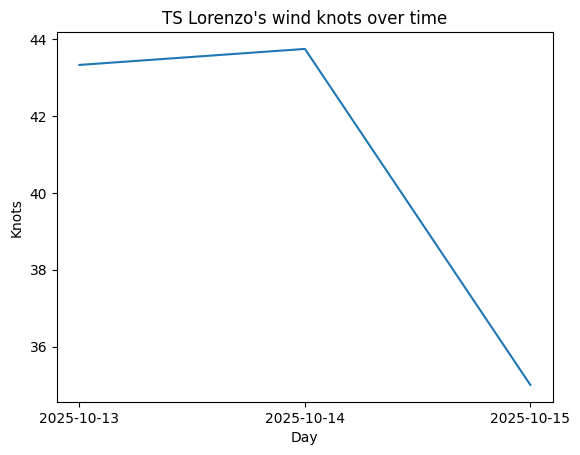

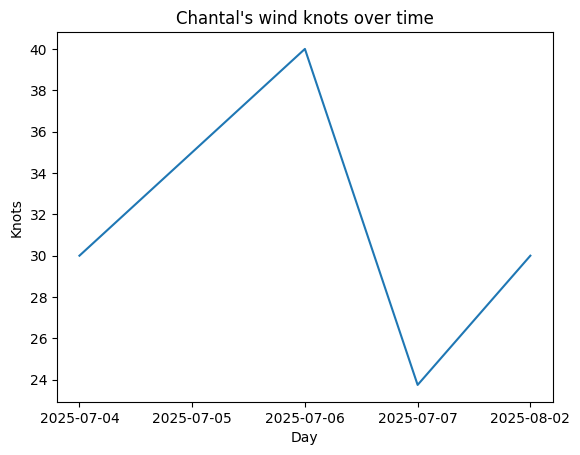

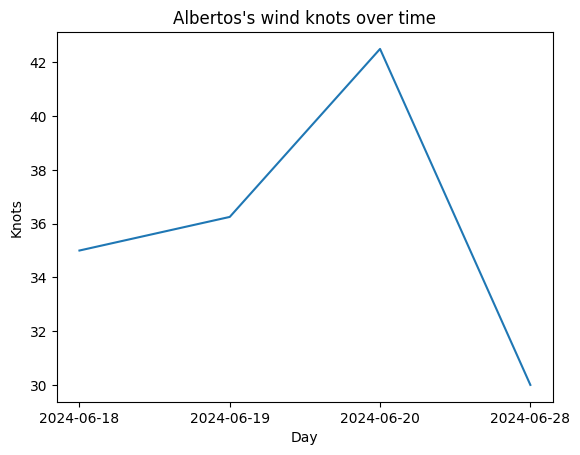

In [16]:
#NOTE: this was a tropical storm(the entire time), meaning the wind speed is slower than a hurricane
#again, the lower the mb, the higher the knot
df_l_knot = df_lorenzo.groupby('date')['max_wind_knots'].mean()
df_l_knot = df_l_knot.reset_index()

plt.plot(df_l_knot['date'], df_l_knot['max_wind_knots'])

plt.title("TS Lorenzo's wind knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()
################################################################################
df_c_knot = df_chantal.groupby('date')['max_wind_knots'].mean()
df_c_knot = df_c_knot.reset_index()

plt.plot(df_c_knot['date'], df_c_knot['max_wind_knots'])

plt.title("Chantal's wind knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()
################################################################################
df_a_knot = df_alberto.groupby('date')['max_wind_knots'].mean()
df_a_knot = df_a_knot.reset_index()

plt.plot(df_a_knot['date'], df_a_knot['max_wind_knots'])

plt.title("Albertos's wind knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()

____________________

In [17]:
#notes for self :)
#as_index does the same thing as reset_index() - it turns the index into a columns of a df
#.agg 'combindes' the multiple rows of each storm into one row by caculating the average and more
#the big chunk at the end just adds columns(min, max, and mean)
df_better = df_nodup.groupby(['storm_id', 'name'], as_index=False).agg(
    start_date=('date', 'min'),
    end_date=('date', 'max'),
    max_wind_knots=('max_wind_knots', 'max'),
    min_wind_knots=('max_wind_knots', 'min'),
    avg_wind_knots=('max_wind_knots', 'mean'),
    max_pressure_mb=('min_pressure_mb', 'max'),
    min_pressure_mb=('min_pressure_mb', 'min'),
    avg_pressure_mb=('min_pressure_mb', 'mean')

)

#converts the start and end date to datetime data type
df_better['start_date'] = pd.to_datetime(df_better['start_date'])
df_better['end_date'] = pd.to_datetime(df_better['end_date'])
df_better.dtypes

#computes duration of each hurricane by subtracting the start_date from the end_date.
df_better['duration_days'] = (df_better['end_date'] - df_better['start_date']).dt.days+1

df_better

,storm_id,name,start_date,end_date,max_wind_knots,min_wind_knots,avg_wind_knots,max_pressure_mb,min_pressure_mb,avg_pressure_mb,duration_days
0,AL011851,UNNAMED,1851-06-25,1851-06-28,80,40,60.714286,NaN,NaN,NaN,4
1,AL011852,UNNAMED,1852-08-19,1852-08-30,100,40,73.333333,961.0,961.0,961.000000,12
2,AL011853,UNNAMED,1853-08-05,1853-08-05,50,50,50.000000,NaN,NaN,NaN,1
3,AL011854,UNNAMED,1854-06-25,1854-06-27,70,40,58.181818,NaN,NaN,NaN,3
4,AL011855,UNNAMED,1855-08-06,1855-08-06,90,90,90.000000,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
1999,AL301969,UNNAMED,1969-08-07,1969-08-08,30,25,29.000000,NaN,NaN,NaN,2
2000,AL302005,EPSILON,2005-11-29,2005-12-09,75,25,54.883721,1009.0,981.0,991.511628,11
2001,AL302020,THETA,2020-11-08,2020-11-16,60,25,42.121212,1014.0,987.0,998.939394,9
2002,AL312005,ZETA,2005-12-30,2006-01-07,55,25,42.361111,1016.0,994.0,1001.583333,9


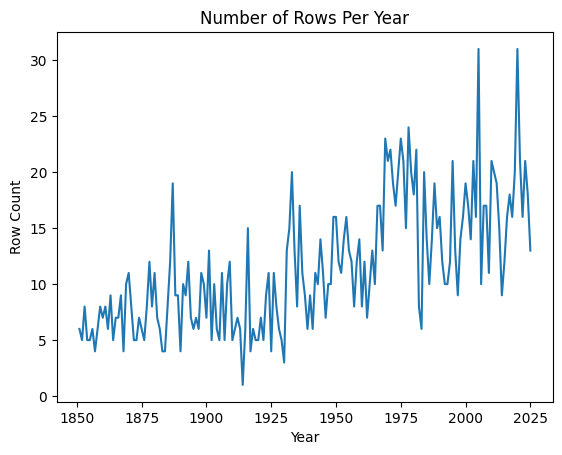

In [45]:
df_better['year'] = df_better['start_date'].dt.year

yearly_counts = df_better['year'].value_counts().sort_index()

plt.plot(yearly_counts.index, yearly_counts.values)
plt.title('Number of Rows Per Year')
plt.xlabel('Year')
plt.ylabel('Row Count')
plt.show()

In [46]:
#1960 bcs there is a change in the amount of hurricanes after that year(more)
df_filtered=df_better[df_better['year']>=1960]
df_filtered

,storm_id,name,start_date,end_date,max_wind_knots,min_wind_knots,avg_wind_knots,max_pressure_mb,min_pressure_mb,avg_pressure_mb,duration_days,year
109,AL011960,UNNAMED,1960-06-22,1960-06-28,50,20,28.888889,1013.0,1000.0,1007.000000,7,1960
110,AL011961,ANNA,1961-07-17,1961-07-25,90,30,60.156250,1002.0,976.0,987.538462,9,1961
111,AL011962,ALMA,1962-08-26,1962-09-02,75,25,46.250000,1007.0,984.0,995.375000,8,1962
112,AL011963,ARLENE,1963-07-31,1963-08-14,100,25,46.545455,1012.0,969.0,989.230769,15,1963
113,AL011964,UNNAMED,1964-06-03,1964-06-11,60,25,38.382353,1007.0,992.0,999.833333,9,1964
...,...,...,...,...,...,...,...,...,...,...,...,...
1999,AL301969,UNNAMED,1969-08-07,1969-08-08,30,25,29.000000,NaN,NaN,NaN,2,1969
2000,AL302005,EPSILON,2005-11-29,2005-12-09,75,25,54.883721,1009.0,981.0,991.511628,11,2005
2001,AL302020,THETA,2020-11-08,2020-11-16,60,25,42.121212,1014.0,987.0,998.939394,9,2020
2002,AL312005,ZETA,2005-12-30,2006-01-07,55,25,42.361111,1016.0,994.0,1001.583333,9,2005


In [47]:
#if a hurricane lasts 7 or more days, consider it a 'long' hurricane. I tried other nearby values, there were no big differences.
#takes the average of the min/max/avg wind knots and the mb of two groups(7 days and longer or less than a weeek)

cutoff=7
df_filtered['longer']=df_filtered['duration_days']>=cutoff
df_plot=df_filtered.groupby(['longer'],as_index=False).agg(
    avg_duration_days=('duration_days','mean'),
    avg_max_wind_knots = ('max_wind_knots','mean'),
    avg_min_wind_knots = ('min_wind_knots','mean'),
    avg_avg_wind_knots = ('avg_wind_knots','mean'),
    avg_max_pressure_mb=('max_pressure_mb','mean'),
    avg_min_pressure_mb =('min_pressure_mb','mean'),
    avg_avg_pressure_mb = ('avg_pressure_mb','mean')
)
df_plot

/tmp/ipykernel_626/2464420523.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['longer']=df_filtered['duration_days']>=cutoff


,longer,avg_duration_days,avg_max_wind_knots,avg_min_wind_knots,avg_avg_wind_knots,avg_max_pressure_mb,avg_min_pressure_mb,avg_avg_pressure_mb
0,False,4.176685,44.972678,13.214936,33.182247,1009.025126,996.389447,1003.048220
1,True,11.257198,82.485605,23.798464,50.140985,1008.942116,970.441118,992.244796


Text(0, 0.5, 'Average Maximum Wind Speed(knots)')

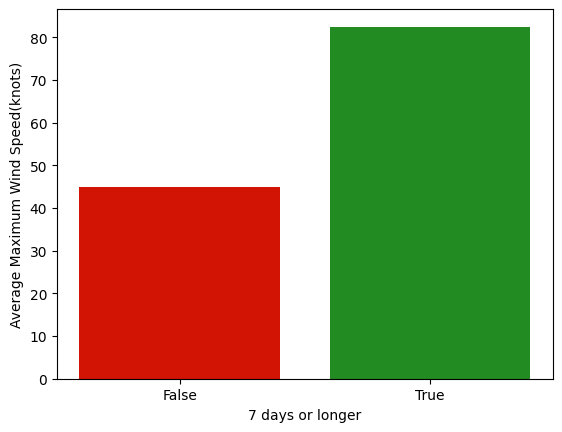

In [55]:
df_plot[['longer','avg_avg_wind_knots']]

#longer is a boolean, so the x axis would be numbers(neg for false, pos for true), so you have to convert it into a str
plt.bar(df_plot['longer'].astype(str), df_plot['avg_max_wind_knots'], color = ['#D21404', '#228B22'])

plt.xlabel('7 days or longer')
plt.ylabel('Average Maximum Wind Speed(knots)')

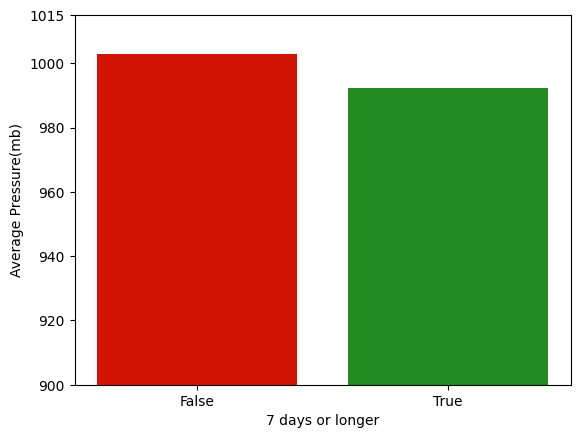

In [54]:
df_plot[['longer','avg_avg_pressure_mb']]

plt.bar(df_plot['longer'].astype(str), df_plot['avg_avg_pressure_mb'], color = ['#D21404', '#228B22'])
plt.ylim(900, 1015)
plt.yticks([900, 920, 940, 960, 980, 1000, 1015])

plt.xlabel('7 days or longer')
plt.ylabel('Average Pressure(mb)')

plt.show()